In [1]:
import os

In [2]:
data_dir = "/kaggle/input/competitions/rsna-knee-abnormality-detection"

for item in os.listdir(data_dir):
    print(item)

test_series.csv
train_series.csv
sample_submission.csv
test_series
train_series
train.csv
test.csv


In [3]:
import pandas as pd

train = pd.read_csv(f"{data_dir}/train.csv")
test = pd.read_csv(f"{data_dir}/test.csv")

#training data
print("training data: ", train.head())
print(train.columns.tolist())
print("shape:", train.shape)


#testing data
print("test data:", test.head())
print(test.columns.tolist())
print("shape:",test.shape)

training data:                                      StudyInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...   
1  1.2.826.0.1.3680043.8.498.10004945927472656027...   
2  1.2.826.0.1.3680043.8.498.10009278692606631573...   
3  1.2.826.0.1.3680043.8.498.10009639203170750274...   
4  1.2.826.0.1.3680043.8.498.10013663742400736029...   

                                              Report  ACL  MCL  \
0  Técnica: RMN de la rodilla. Resultados: Rotura...  NaN  NaN   
1  [DATE]: * MR Knie Rechts 15ch AA Klinische Inl...  NaN  NaN   
2  Hallazgos:\nNo hay alteraciones en significati...  NaN  NaN   
3   In the medial compartment, the meniscus is no...  NaN  NaN   
4  CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...  NaN  NaN   

   Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusion  \
0              NaN               NaN        NaN         NaN    NaN       NaN   
1              NaN               NaN        NaN         NaN    NaN       NaN   
2         

In [4]:
print(train.isnull().sum())

StudyInstanceUID       0
Report                 0
ACL                 4349
MCL                 4349
Medial Meniscus     4349
Lateral Meniscus    4349
Medial OA           4349
Lateral OA          4349
PF OA               4349
Effusion            4349
Synovitis           4349
Baker's             4349
Contusion           4349
Fracture            4349
dtype: int64


In [5]:
gold_data = train[train['Fracture'].notna()]
print(gold_data[['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']])

                                       StudyInstanceUID  \
29    1.2.826.0.1.3680043.8.498.10095687747295410396...   
63    1.2.826.0.1.3680043.8.498.10170898615867673028...   
109   1.2.826.0.1.3680043.8.498.10306159113324811538...   
445   1.2.826.0.1.3680043.8.498.11287937729196958426...   
470   1.2.826.0.1.3680043.8.498.11382021393803389951...   
533   1.2.826.0.1.3680043.8.498.11548045715264151632...   
537   1.2.826.0.1.3680043.8.498.11557620559191469069...   
607   1.2.826.0.1.3680043.8.498.11771393824519892797...   
632   1.2.826.0.1.3680043.8.498.11851412923016044948...   
656   1.2.826.0.1.3680043.8.498.11915937982684988073...   
849   1.2.826.0.1.3680043.8.498.12448079646359892252...   
869   1.2.826.0.1.3680043.8.498.12505035424093604269...   
906   1.2.826.0.1.3680043.8.498.12606657226568558340...   
981   1.2.826.0.1.3680043.8.498.12801308844398614687...   
1027  1.2.826.0.1.3680043.8.498.12978510157202852202...   
1150  1.2.826.0.1.3680043.8.498.13267780356245120052... 

In [6]:
train_series = pd.read_csv(f"{data_dir}/train_series.csv")
test_series = pd.read_csv(f"{data_dir}/test_series.csv")


print("train series: ", train_series.head())
print("size : ", train_series.size)
print(train_series.columns.tolist())

print("test series: ", test_series.head())
print("size : ",test_series.size)
print(test_series.columns.tolist())

train series:                                      StudyInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...   
1  1.2.826.0.1.3680043.8.498.10004873229099053869...   
2  1.2.826.0.1.3680043.8.498.10004873229099053869...   
3  1.2.826.0.1.3680043.8.498.10004873229099053869...   
4  1.2.826.0.1.3680043.8.498.10004873229099053869...   

                                   SeriesInstanceUID  Fluid_Sensitive  \
0  1.2.826.0.1.3680043.8.498.12343110195036213483...                1   
1  1.2.826.0.1.3680043.8.498.13821229744997220641...                1   
2  1.2.826.0.1.3680043.8.498.23084836536722595275...                0   
3  1.2.826.0.1.3680043.8.498.40734206102458723096...                1   
4  1.2.826.0.1.3680043.8.498.75714899997203615784...                0   

   Fat_Suppression Anatomical_Plane  
0                1         Sagittal  
1                1            Axial  
2                0          Coronal  
3                1          Coronal  
4                0 

In [7]:
# Understanding the train_series file

study_id = train_series['StudyInstanceUID'].iloc[0]
series_id = train_series['SeriesInstanceUID'].iloc[0]

print("study_ids: ",os.listdir(f"{data_dir}/train_series")[:5])  # study_ids

print("series_ids: " ,os.listdir(f"{data_dir}/train_series/{study_id}"))  #series_ids

print(".dcm files: ", os.listdir(f"{data_dir}/train_series/{study_id}/{series_id}"))  #.dcm files

study_ids:  ['1.2.826.0.1.3680043.8.498.10843463954622076609489312662891432839', '1.2.826.0.1.3680043.8.498.11425683153901568541658945026861110110', '1.2.826.0.1.3680043.8.498.68524920268469128133836299591793117756', '1.2.826.0.1.3680043.8.498.65222333228514862688331581862087607325', '1.2.826.0.1.3680043.8.498.27653320597564308144389724321115208375']
series_ids:  ['1.2.826.0.1.3680043.8.498.13821229744997220641575291927426543265', '1.2.826.0.1.3680043.8.498.75714899997203615784077798038670363546', '1.2.826.0.1.3680043.8.498.40734206102458723096154687147390476697', '1.2.826.0.1.3680043.8.498.23084836536722595275828690293168736174', '1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772']
.dcm files:  ['1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435.dcm', '1.2.826.0.1.3680043.8.498.11560456494251875828657453454342564666.dcm', '1.2.826.0.1.3680043.8.498.62696444312933722854177245172284641767.dcm', '1.2.826.0.1.3680043.8.498.132704163601660700272755551708528055

In [8]:
# dcm file 

import pydicom

dcm_files = os.listdir(f"{data_dir}/train_series/{study_id}/{series_id}")
sample_path = f"{data_dir}/train_series/{study_id}/{series_id}/{dcm_files[0]}"

dcm = pydicom.dcmread(sample_path)
print(dcm)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 148
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
-------------------------------------------------
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M_SE', 'M', 'SE']
(0008,0016) SOP Class UID                       UI: MR Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435
(0008,0060) Modality                            CS: 'MR'
(0008,0070) Manufacturer                        LO: 'Philips Healthcare'
(0008,103E) Series Description                  LO: 'DP SPIR CS_SAG'
(0008,1090) Manufacturer's Model Nam

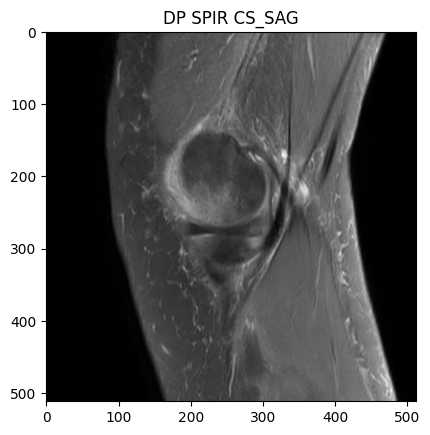

In [9]:
import matplotlib.pyplot as plt

plt.imshow(dcm.pixel_array, cmap='gray')
plt.title(dcm.SeriesDescription)
plt.show()

In [10]:
# Total MRI images in first file
slices = []
for file in dcm_files:
    d = pydicom.dcmread(f"{data_dir}/train_series/{study_id}/{series_id}/{file}")
    slices.append(d)

print(len(slices))

22


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


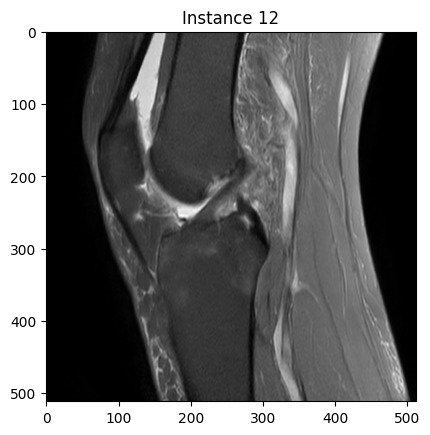

In [11]:
# Middle Slice for MRI scans of first file
slices_sorted = sorted(slices, key = lambda d: int(d.InstanceNumber))
print([int(s.InstanceNumber) for s in slices_sorted])

mid = slices_sorted[len(slices_sorted)//2]
plt.imshow(mid.pixel_array, cmap='gray')
plt.title(f"Instance {mid.InstanceNumber}")
plt.show()

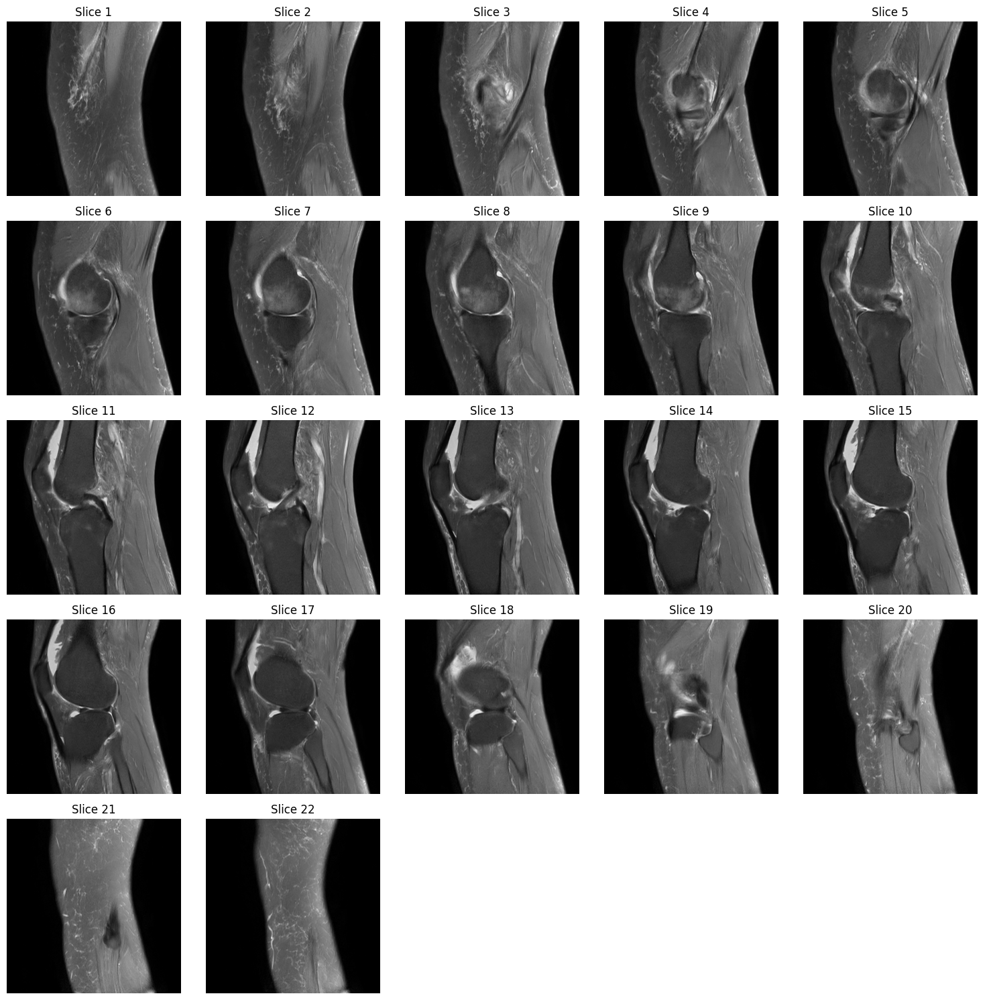

In [12]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15)) 

for i, ax in enumerate(axes.flat):
    if i < len(slices_sorted):
        ax.imshow(slices_sorted[i].pixel_array, cmap='gray')
        ax.set_title(f"Slice {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()

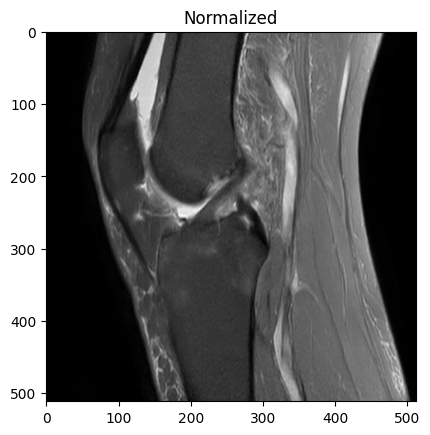

In [13]:
import numpy as np

volume = np.stack([s.pixel_array for s in slices_sorted])

volume_norm = (volume-volume.min())/(volume.max()-volume.min())
plt.imshow(volume_norm[11], cmap = "gray")
plt.title("Normalized")
plt.show()

In [14]:
# ALL MASTER FUNCTIONS

# series volumne function
def load_series(study_id, series_id):
    folder = f"{data_dir}/train_series/{study_id}/{series_id}"
    dcm_files = os.listdir(folder)

    slices = [pydicom.dcmread(f"{folder}/{f}") for f in dcm_files]
    slices_sorted = sorted(slices, key=lambda d: int(d.InstanceNumber))

    volume = np.stack([s.pixel_array for s in slices_sorted])
    volume_norm = (volume-volume.min())/(volume.max()-volume.min())

    return volume_norm.astype(np.float32)


# selecting the 3 Anatomical Plane from series
def select_series(study_id):
    study_series = train_series[train_series['StudyInstanceUID'] == study_id]
    selected = {}
    for plane in ['Sagittal', 'Coronal', 'Axial']:
        plane_series = study_series[study_series['Anatomical_Plane'] == plane]
        chosen = plane_series[plane_series['Fluid_Sensitive']==1]
        if len(chosen) == 0:
            chosen = plane_series
        selected[plane] = chosen.iloc[0]['SeriesInstanceUID']
    return selected


# Resizing the scans
from scipy.ndimage import zoom

def resize_volume(volume, target_shape = (24, 256, 256)):
    factors = [t/s for t,s in zip(target_shape, volume.shape)]
    resized = zoom(volume, factors, order=1)
    return resized.astype(np.float32)


# full study pipeline
def load_study(study_id, target_shape = (24,256,256)):
    series_map = select_series(study_id)
    volumes = {}
    for plane, series_id in series_map.items():
        vol = load_series(study_id, series_id)
        vol = resize_volume(vol, target_shape)
        volumes[plane] = vol
    return volumes



# visuals of all scan --- function
def all_scans(study_id, series_id):
    folder = f"{data_dir}/train_series/{study_id}/{series_id}"
    dcm_files = os.listdir(folder)

    slices = [pydicom.dcmread(f"{folder}/{f}") for f in dcm_files]
    slices_sorted = sorted(slices, key=lambda d: int(d.InstanceNumber))
    
    fig, axes = plt.subplots(5, 5, figsize=(15, 15)) 
    
    for i, ax in enumerate(axes.flat):
        if i < len(slices_sorted):
            ax.imshow(slices_sorted[i].pixel_array, cmap='bone')
            ax.set_title(f"Slice {i+1}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [15]:
# Fixed test IDs — only for testing purpose
TEST_STUDY_ID = train['StudyInstanceUID'].iloc[0]
TEST_SERIES_ID = select_series(TEST_STUDY_ID)['Sagittal']


# Mappings for Anatomical Plane
series_map = select_series(TEST_STUDY_ID)

TEST_SAGITTAL = series_map['Sagittal']
TEST_CORONAL = series_map['Coronal']
TEST_AXIAL = series_map['Axial']

(22, 512, 512) 0.0 1.0


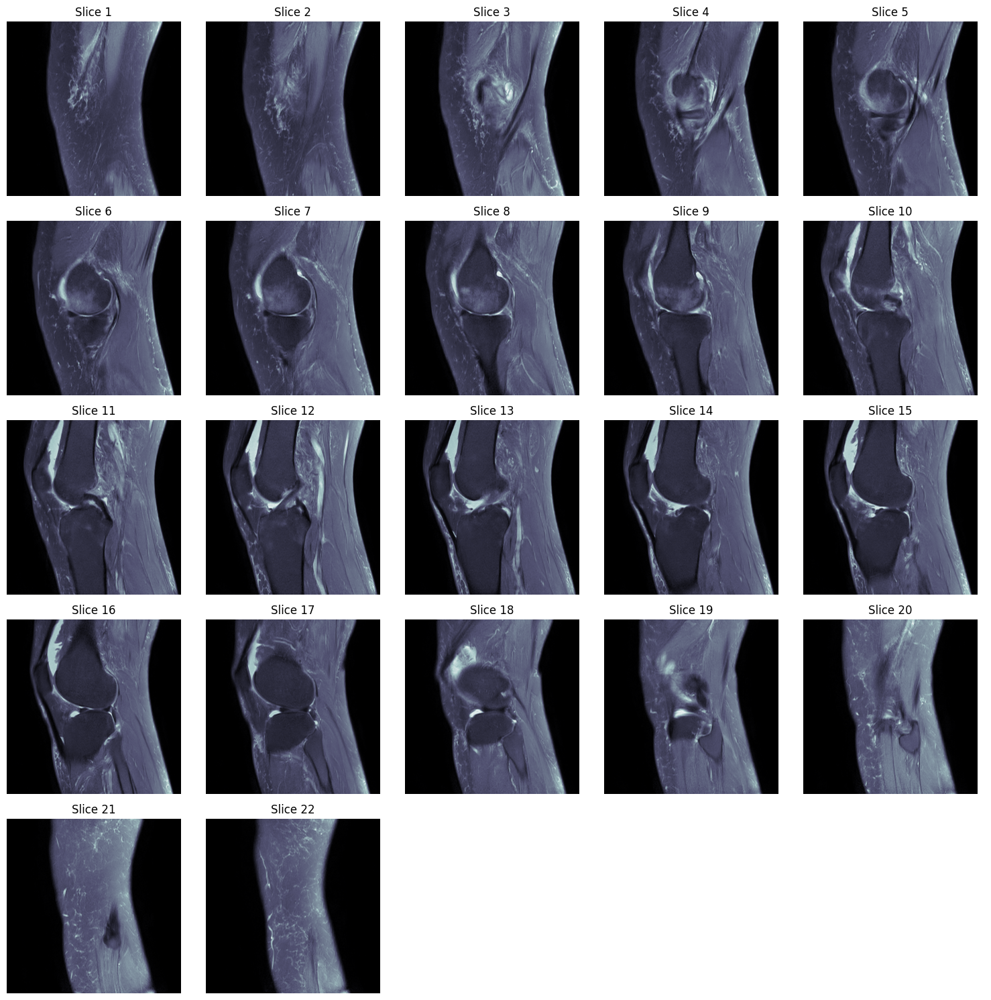

In [16]:
volume = load_series(study_id, series_id)
print(volume.shape, volume.min(), volume.max())

all_scans(study_id, series_id)

In [17]:
study_series_info = train_series[train_series['StudyInstanceUID']==study_id]
print(study_series_info)

print(study_series_info.shape)
print(study_series_info['Anatomical_Plane'].value_counts())
print(study_series_info[['Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']].value_counts())

                                    StudyInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...   
1  1.2.826.0.1.3680043.8.498.10004873229099053869...   
2  1.2.826.0.1.3680043.8.498.10004873229099053869...   
3  1.2.826.0.1.3680043.8.498.10004873229099053869...   
4  1.2.826.0.1.3680043.8.498.10004873229099053869...   

                                   SeriesInstanceUID  Fluid_Sensitive  \
0  1.2.826.0.1.3680043.8.498.12343110195036213483...                1   
1  1.2.826.0.1.3680043.8.498.13821229744997220641...                1   
2  1.2.826.0.1.3680043.8.498.23084836536722595275...                0   
3  1.2.826.0.1.3680043.8.498.40734206102458723096...                1   
4  1.2.826.0.1.3680043.8.498.75714899997203615784...                0   

   Fat_Suppression Anatomical_Plane  
0                1         Sagittal  
1                1            Axial  
2                0          Coronal  
3                1          Coronal  
4                0         Sagitta

In [18]:
series_per_study = train_series.groupby('StudyInstanceUID').size()
print(series_per_study.describe())

count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64


In [19]:
plane_presence = train_series.groupby('StudyInstanceUID')['Anatomical_Plane'].apply(lambda x: set(x))
print(plane_presence.apply(lambda x: 'Sagittal' in x).value_counts())
print(plane_presence.apply(lambda x: 'Coronal' in x).value_counts())
print(plane_presence.apply(lambda x: 'Axial' in x).value_counts())

Anatomical_Plane
True    4407
Name: count, dtype: int64
Anatomical_Plane
True    4407
Name: count, dtype: int64
Anatomical_Plane
True    4407
Name: count, dtype: int64


study id: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260  series id: 1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772


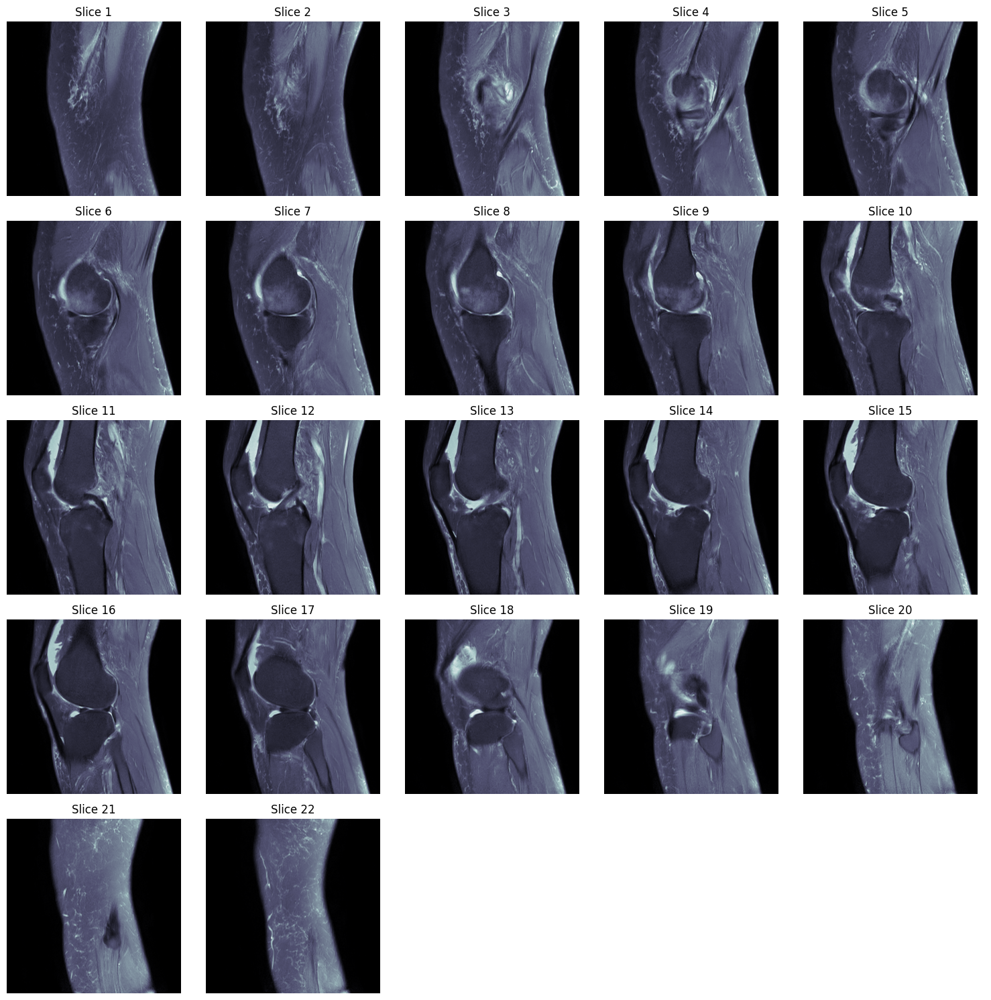

study id: 1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585  series id: 1.2.826.0.1.3680043.8.498.27845969797953115400959653384511165237


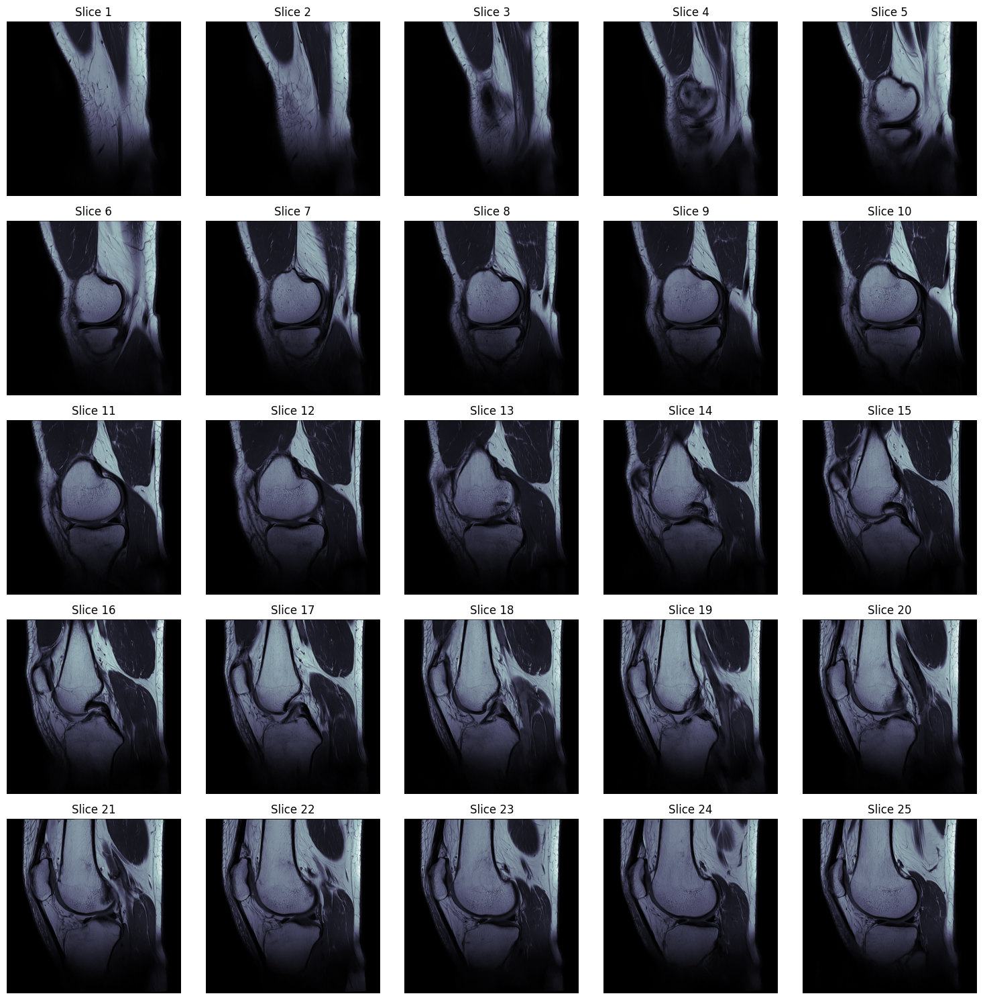

study id: 1.2.826.0.1.3680043.8.498.10009278692606631573540062909909132231  series id: 1.2.826.0.1.3680043.8.498.12689544351656485342798482846432921455


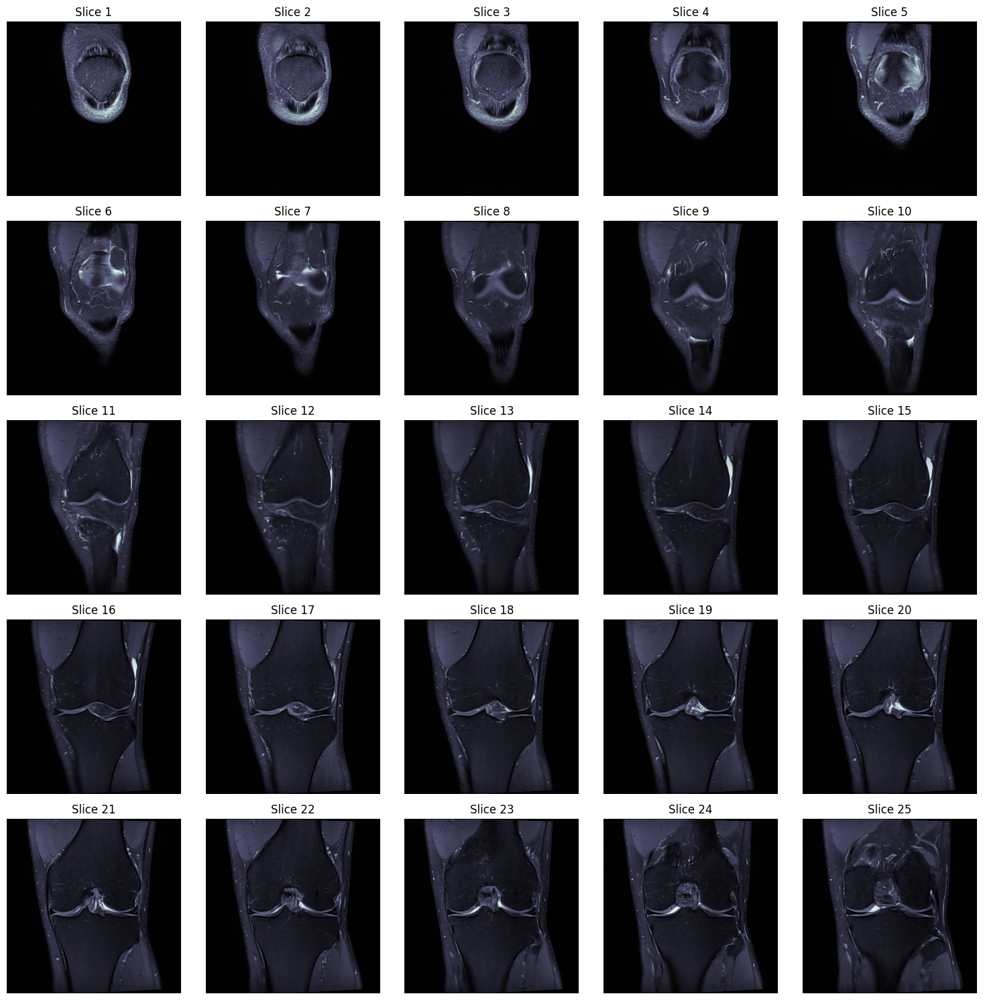

study id: 1.2.826.0.1.3680043.8.498.10009639203170750274174707434356622764  series id: 1.2.826.0.1.3680043.8.498.10407754553908392233077656347467111543


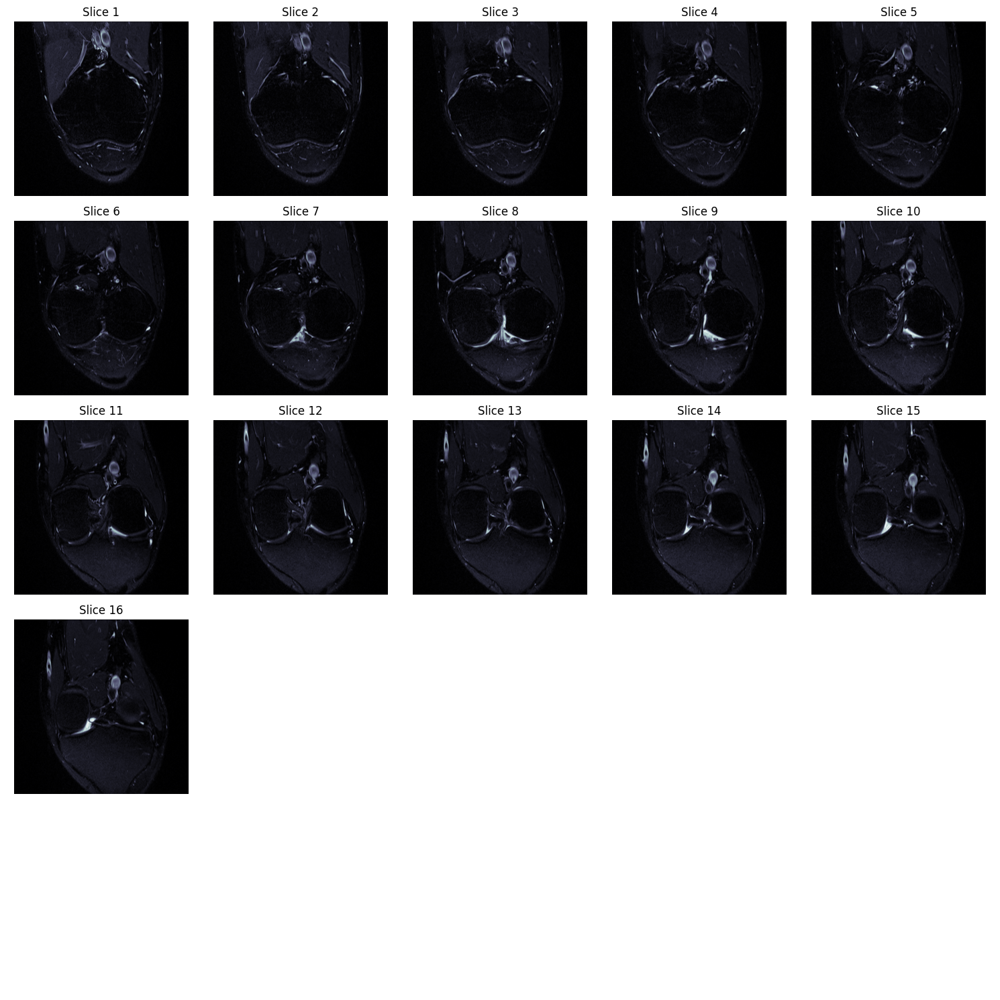

study id: 1.2.826.0.1.3680043.8.498.10013663742400736029415768216599146542  series id: 1.2.826.0.1.3680043.8.498.11982164807463634778369544669639739403


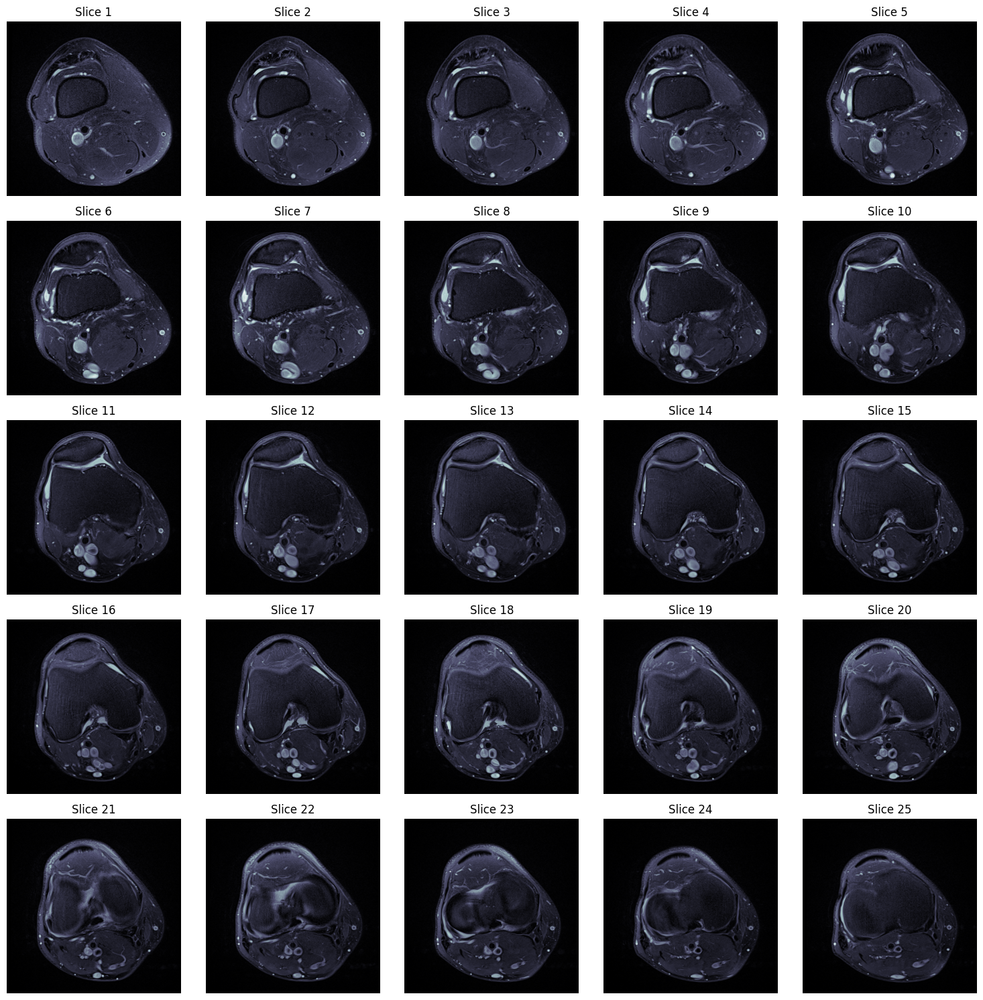

In [20]:
for i in range(0, 5):
    study_id = train['StudyInstanceUID'].iloc[i]  # train se — 5 alag studies
    
    # is study ki saari series nikaalo, pehli wali le lo
    study_series = train_series[train_series['StudyInstanceUID'] == study_id]
    series_id = study_series['SeriesInstanceUID'].iloc[0]
    
    print(f"study id: {study_id}  series id: {series_id}")
    all_scans(study_id, series_id)

In [21]:
# consistency check

for sid in train['StudyInstanceUID'].iloc[:5]:
    result = select_series(sid)
    print(sid, "=", result)

1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260 = {'Sagittal': '1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772', 'Coronal': '1.2.826.0.1.3680043.8.498.40734206102458723096154687147390476697', 'Axial': '1.2.826.0.1.3680043.8.498.13821229744997220641575291927426543265'}
1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585 = {'Sagittal': '1.2.826.0.1.3680043.8.498.72137122913943091996840828871969421711', 'Coronal': '1.2.826.0.1.3680043.8.498.99023014295026495734071089488213553280', 'Axial': '1.2.826.0.1.3680043.8.498.83327574802189551711953505990029424266'}
1.2.826.0.1.3680043.8.498.10009278692606631573540062909909132231 = {'Sagittal': '1.2.826.0.1.3680043.8.498.93288538765996574291399549037773479273', 'Coronal': '1.2.826.0.1.3680043.8.498.12689544351656485342798482846432921455', 'Axial': '1.2.826.0.1.3680043.8.498.26515132645256697953312631089055309042'}
1.2.826.0.1.3680043.8.498.10009639203170750274174707434356622764 = {'Sagittal': '1.2.826

In [22]:
study_volumes = load_study(study_id)
for plane, vol in study_volumes.items():
    print(plane, vol.shape)

Sagittal (24, 256, 256)
Coronal (24, 256, 256)
Axial (24, 256, 256)


In [23]:
# checking the resolution of scans
import pydicom

rows_list = []
cols_list = []

for sid in train['StudyInstanceUID'].iloc[:20]:
    try:
        series_map = select_series(sid)
        for plane, series_id in series_map.items():
            folder = f"{data_dir}/train_series/{sid}/{series_id}"
            first_file = os.listdir(folder)[0]
            d = pydicom.dcmread(f"{folder}/{first_file}")
            rows_list.append(d.Rows)
            cols_list.append(d.Columns)
    except Exception as e:
        print(sid, "error:", e)

print(set(rows_list))
print(set(cols_list))

{512, 768, 640, 416, 320, 384, 800, 704, 448, 576, 560, 464, 496, 528, 792}
{512, 768, 640, 416, 320, 384, 800, 704, 576, 490, 462, 560, 464, 528, 540}


In [24]:
resized = resize_volume(study_volumes['Sagittal'])
print(resized.shape)

(24, 256, 256)


In [25]:
study_volumes = load_study(study_id)
for plane, vol in study_volumes.items():
    print(plane, vol.shape)

Sagittal (24, 256, 256)
Coronal (24, 256, 256)
Axial (24, 256, 256)


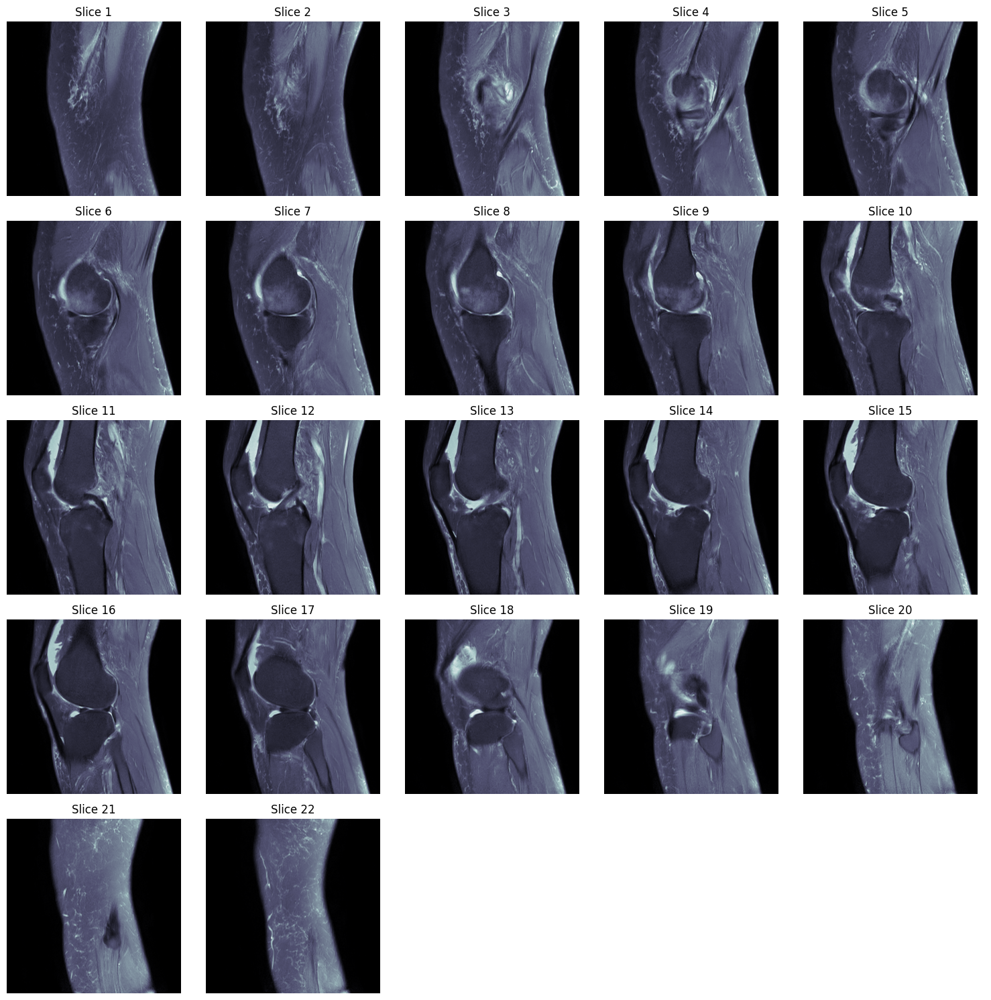

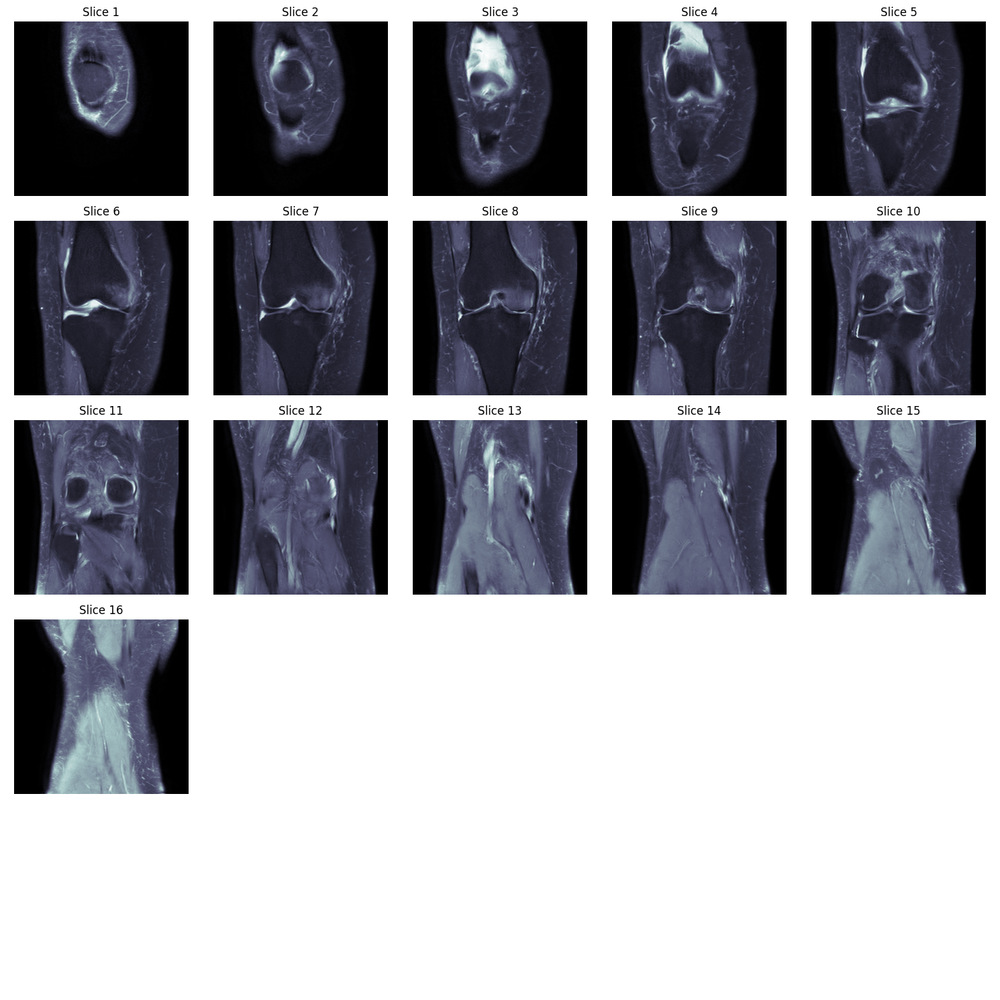

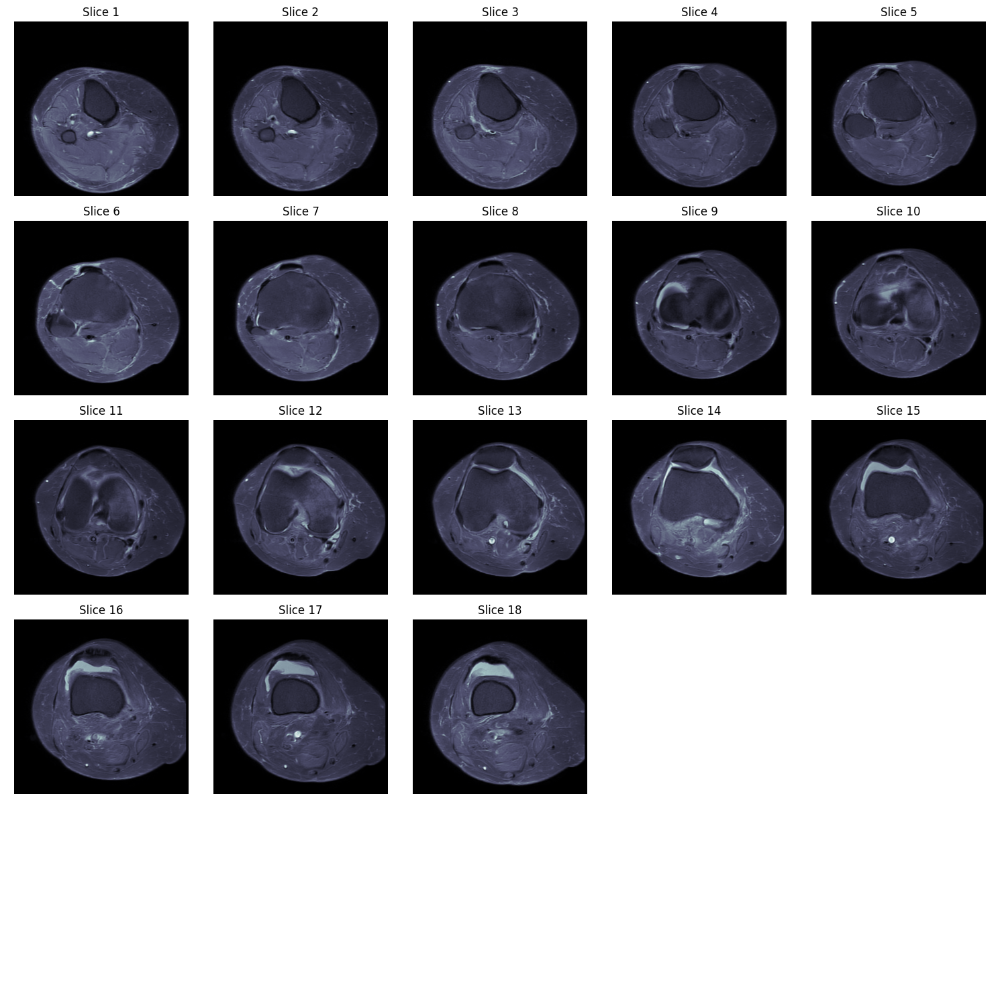

In [26]:
all_scans(TEST_STUDY_ID, TEST_SAGITTAL)
all_scans(TEST_STUDY_ID, TEST_CORONAL)
all_scans(TEST_STUDY_ID, TEST_AXIAL)

In [27]:
report_label = pd.read_csv("/kaggle/input/datasets/mayankptdr/report-labels/extracted_labels.csv")

In [28]:
print(report_label.head())
print(report_label.shape)

                                    StudyInstanceUID  ACL  MCL  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...    0    0   
1  1.2.826.0.1.3680043.8.498.10004945927472656027...    0    0   
2  1.2.826.0.1.3680043.8.498.10009278692606631573...    0    0   
3  1.2.826.0.1.3680043.8.498.10009639203170750274...    0    0   
4  1.2.826.0.1.3680043.8.498.10013663742400736029...    0    1   

   Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusion  \
0                1               0.0          1           0      0         1   
1                0               0.0          0           0      0         0   
2                0               0.0          1           0      1         0   
3                0               0.0          0           0      0         0   
4                0               0.0          1           1      1         0   

   Synovitis  Baker's  Contusion  Fracture  
0          0        0          0         0  
1          0        0          0

In [29]:
finding_columns = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 
                    'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 
                    'Contusion', 'Fracture']

# gold label from gold data
gold_labels = gold_data[['StudyInstanceUID'] + finding_columns].copy()

# concatination of gold data + LLM extracted data
all_labels = pd.concat([gold_labels, report_label], ignore_index=True)

print(all_labels.shape) 
print(all_labels['StudyInstanceUID'].nunique()) 
print(all_labels.isnull().sum()) 

(4407, 13)
4407
StudyInstanceUID    0
ACL                 0
MCL                 0
Medial Meniscus     0
Lateral Meniscus    1
Medial OA           0
Lateral OA          0
PF OA               0
Effusion            0
Synovitis           0
Baker's             0
Contusion           0
Fracture            0
dtype: int64


In [30]:
# Handlikng the missing value
all_labels[finding_columns] = all_labels[finding_columns].fillna(0)
print(all_labels.isnull().sum())

StudyInstanceUID    0
ACL                 0
MCL                 0
Medial Meniscus     0
Lateral Meniscus    0
Medial OA           0
Lateral OA          0
PF OA               0
Effusion            0
Synovitis           0
Baker's             0
Contusion           0
Fracture            0
dtype: int64


## Dataset and DataLoader

In [31]:
import torch
from torch.utils.data import Dataset

class KneeMRIDataset(Dataset):
    def __init__(self, labels_df, target_shape = (24,256,256)):
        self.labels_df = labels_df.reset_index(drop=True)
        self.target_shape = target_shape
        self.finding_columns = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        study_id = row['StudyInstanceUID']

        volumes = load_study(study_id, self.target_shape)

        sagittal = torch.tensor(volumes['Sagittal'], dtype=torch.float32)
        coronal = torch.tensor(volumes['Coronal'], dtype=torch.float32)
        axial = torch.tensor(volumes['Axial'], dtype=torch.float32)

        labels = torch.tensor(row[self.finding_columns].values.astype(float), dtype=torch.float32)
        
        return {
            'sagittal': sagittal,
            'coronal': coronal,
            'axial': axial,
            'labels': labels,
            'study_id': study_id
        }

In [32]:
dataset = KneeMRIDataset(all_labels)
sample = dataset[0]

print(sample['sagittal'].shape)
print(sample['coronal'].shape)
print(sample['axial'].shape)
print(sample['labels'])
print(sample['study_id'])

torch.Size([24, 256, 256])
torch.Size([24, 256, 256])
torch.Size([24, 256, 256])
tensor([0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.])
1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149


In [33]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(loader))
print(batch['sagittal'].shape)
print(batch['labels'].shape)

torch.Size([4, 24, 256, 256])
torch.Size([4, 12])


In [34]:
CHUNK_NUMBER = 1 

all_study_ids = all_labels['StudyInstanceUID'].tolist()
chunk_size = len(all_study_ids) // 5

chunks = {
    1: all_study_ids[:chunk_size],
    2: all_study_ids[chunk_size:2*chunk_size],
    3: all_study_ids[2*chunk_size:3*chunk_size],
    4: all_study_ids[3*chunk_size:4*chunk_size],
    5: all_study_ids[4*chunk_size:]
}

my_chunk = chunks[CHUNK_NUMBER]
print(f"Chunk {CHUNK_NUMBER}: {len(my_chunk)} studies assigned")

Chunk 1: 881 studies assigned


In [35]:
import shutil
cache_dir = "/kaggle/working/cached_volumes"
os.makedirs(cache_dir, exist_ok=True)

def build_cache(study_ids, target_shape=(24, 256, 256)):
    for study_id in study_ids:
        cache_path = f"{cache_dir}/{study_id}.npz"
        
        if os.path.exists(cache_path):
            continue
        
        total, used, free = shutil.disk_usage("/kaggle/working")
        free_gb = free / (1024**3)
        if free_gb < 1.0:
            print(f"Disk space low ({free_gb:.2f} GB free). Stopping safely.")
            break
        
        try:
            volumes = load_study(study_id, target_shape)
            np.savez_compressed(cache_path,
                                 sagittal=volumes['Sagittal'],
                                 coronal=volumes['Coronal'],
                                 axial=volumes['Axial'])
            print(f"Cached: {study_id}")
        except Exception as e:
            print(f"Error on {study_id}: {e}")

build_cache(my_chunk)

Cached: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
Cached: 1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269
Cached: 1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052
Cached: 1.2.826.0.1.3680043.8.498.11287937729196958426538087439102017580
Cached: 1.2.826.0.1.3680043.8.498.11382021393803389951964005983002209238
Cached: 1.2.826.0.1.3680043.8.498.11548045715264151632153040089882701935
Cached: 1.2.826.0.1.3680043.8.498.11557620559191469069130827959098335840
Cached: 1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756
Cached: 1.2.826.0.1.3680043.8.498.11851412923016044948101698015974810604
Cached: 1.2.826.0.1.3680043.8.498.11915937982684988073644209606907169581
Cached: 1.2.826.0.1.3680043.8.498.12448079646359892252441208258836556945
Cached: 1.2.826.0.1.3680043.8.498.12505035424093604269515328931488770819
Cached: 1.2.826.0.1.3680043.8.498.12606657226568558340797193167488111973
Cached: 1.2.826.0.1.3680043.8.498.12801308844398614